## Configuration

### imports

In [1]:
## imports

# libraries
import os
import re

import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# custom
from Dense_Unet_Centroid import *
from result_2D_utilities import *

print(tf.__version__)

2.4.0


In [2]:
# 设置用于训练的GPU
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
# The GPU id to use, usually either "0" or "1"
os.environ["CUDA_VISIBLE_DEVICES"]="1" #"1":train, "0":predict;

### Path Setting

In [3]:
#Linux
rootPath = '/home/shu/Dataset/Dataset-xVertSeg'
SrcmhdFolder = '/Spilt' #'/Resample'

## dataset_train, dataset_val构造

In [7]:
casestrainPath = rootPath + SrcmhdFolder + '/images448/train/*/*.bin'
labelstrainPath = rootPath + SrcmhdFolder + '/Dense448/train/*/*.png'

In [8]:
dataset_train, count_train = dataset_train_build(casestrainPath,labelstrainPath)

['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/train/Splt_image010/148.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/train/Splt_image010/149.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/train/Splt_image010/150.bin'] ['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/train/Splt_image010_Dense/148.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/train/Splt_image010_Dense/149.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/train/Splt_image010_Dense/150.png']


In [9]:
casesvalPath = rootPath + SrcmhdFolder + '/images448/test/*/*.bin'
labelsvalPath = rootPath + SrcmhdFolder + '/Dense448/test/*/*.png'

In [10]:
dataset_val, count_val = dataset_val_build(casesvalPath,labelsvalPath)

['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/148.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/149.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/150.bin'] ['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/148.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/149.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/150.png']


In [11]:
STEPS_PER_EPOCH = count_train//BATCH_SIZE
VALIDATION_STEPS = count_val//BATCH_SIZE

In [12]:
dataset_train,dataset_val

(<PrefetchDataset shapes: ((None, 448, 448, 9), (None, None, None, 1)), types: (tf.float32, tf.float64)>,
 <PrefetchDataset shapes: ((None, 448, 448, 9), (None, None, None, 1)), types: (tf.float32, tf.float64)>)

## 2D-Dense-U-Net训练

In [13]:
train_2D(dataset_train,dataset_val,EPOCHS,STEPS_PER_EPOCH,VALIDATION_STEPS)

------------------------------
Creating and compiling model...
------------------------------
------------------------------
Fitting model...
------------------------------
Epoch 1/30
1677/1677 [==============================] - 169s 85ms/step - loss: 0.0474 - accuracy: 0.9924 - val_loss: 0.0134 - val_accuracy: 0.9878
Epoch 2/30
1677/1677 [==============================] - 144s 86ms/step - loss: 0.0083 - accuracy: 0.9918 - val_loss: 0.0120 - val_accuracy: 0.9878
Epoch 3/30
1677/1677 [==============================] - 145s 87ms/step - loss: 0.0077 - accuracy: 0.9918 - val_loss: 0.0113 - val_accuracy: 0.9878
Epoch 4/30
1677/1677 [==============================] - 145s 87ms/step - loss: 0.0070 - accuracy: 0.9920 - val_loss: 0.0106 - val_accuracy: 0.9878
Epoch 5/30
1677/1677 [==============================] - 146s 87ms/step - loss: 0.0068 - accuracy: 0.9917 - val_loss: 0.0103 - val_accuracy: 0.9878
Epoch 6/30
1677/1677 [==============================] - 146s 87ms/step - loss: 0.0062 - accu

## 2D-Dense-U-Net预测

In [14]:
# 设置用于训练的GPU
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
# The GPU id to use, usually either "0" or "1"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [15]:
test_cases_folders = sorted(os.listdir(rootPath + SrcmhdFolder + '/images448/test/'))#[0:1]
test_labels_folders = sorted(os.listdir(rootPath + SrcmhdFolder + '/Dense448/test/'))#[0:1]

In [16]:
# 2D-Dense-Unet-Centroid-20210918-180412 depth:17
# 2D-Dense-Unet-Centroid-20210919-160627 depth:25

In [17]:
# 依次加载测试数据集并预测
i = 0
for testfile in test_cases_folders:
    casesPath = rootPath + SrcmhdFolder + '/images448/test/' + testfile + '/*.bin'
    labelsPath = rootPath + SrcmhdFolder + '/Dense448/test/' + test_labels_folders[i] + '/*.png'
    # print(casesPath,labelsPath)
    dataset_test = dataset_test_build(casesPath,labelsPath)

    # 预测测试结果
    weight_dir = os.path.join('weights', '2D-Dense-Unet-Centroid-20210921-183719' + '.h5')
    outPath = rootPath + SrcmhdFolder + "/pred_Dense448/" + "pred_" + testfile + "/"
    predict_2D(weight_dir,dataset_test,outPath)
    i = i + 1

['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image011/150.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image011/151.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image011/152.bin'] ['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image011_Dense/150.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image011_Dense/151.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image011_Dense/152.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 38ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image012/177.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image012/178.bin', '/home/shu/Dataset

1/1 [==============================] - 0s 32ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image013/175.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image013/176.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image013/177.bin'] ['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image013_Dense/175.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image013_Dense/176.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image013_Dense/177.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 51ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/Dataset xVertSeg/Spilt/imag

1/1 [==============================] - 0s 39ms/step
------------------------------
Prediction finished
------------------------------
['/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/148.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/149.bin', '/home/shu/Dataset/Dataset xVertSeg/Spilt/images448/test/Splt_image015/150.bin'] ['/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/148.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/149.png', '/home/shu/Dataset/Dataset xVertSeg/Spilt/Dense448/test/Splt_image015_Dense/150.png']
------------------------------
Loading saved weights...
------------------------------
------------------------------
Predicting masks on test data...
------------------------------
1/1 [==============================] - 0s 42ms/step
------------------------------
Prediction finished
------------------------------


## Get predicted centroids

In [27]:
pred_DensePath = rootPath + SrcmhdFolder + '/pred_Dense448/'# /Dense128/test/'

# pred_DensePath = '/home/shu/Dataset/Dataset2-Jack' + '/pred_Dense/'

In [28]:
pred_Dense_folders = sorted(os.listdir(pred_DensePath))#[4:5]

In [29]:
pred_Dense_folders

['pred_Splt_image011',
 'pred_Splt_image012',
 'pred_Splt_image013',
 'pred_Splt_image014',
 'pred_Splt_image015']

[175.71428571 170.71428571 149.57142857 171.         191.85714286]
[ 22  51  76 105 129]


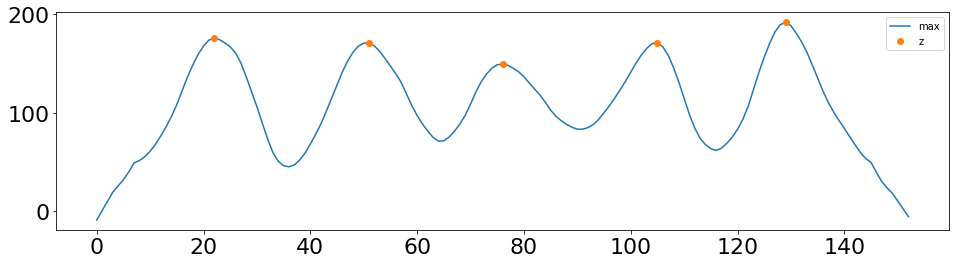

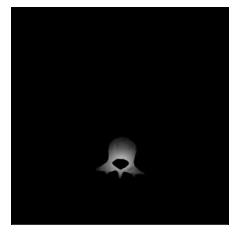

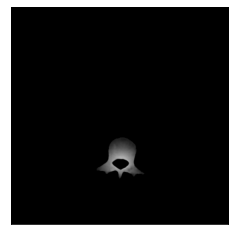

20 180


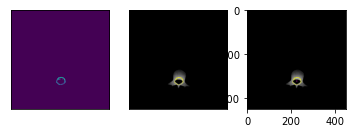

20 180


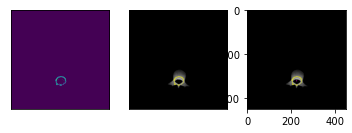

20 180


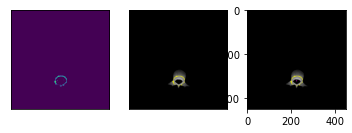

20 180


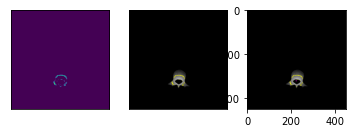

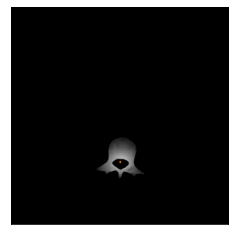

20 176
20 176
20 176
20 176
20 148
20 148
20 148
20 148
20 184
20 184
20 184
20 184
20 197
20 197
20 197
20 197
5
[152.42857143 155.         180.71428571 173.85714286 179.57142857
 117.71428571 118.57142857 146.14285714]
[  7  34  62  89 119 147 162 172]


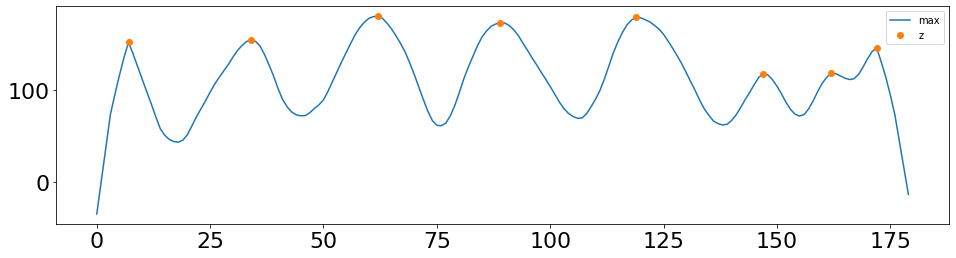

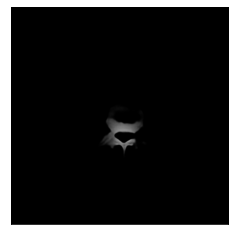

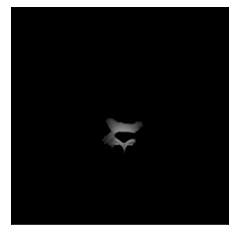

20 155


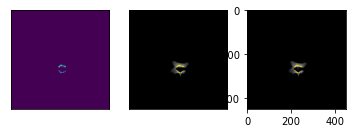

20 155


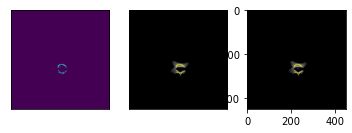

20 155


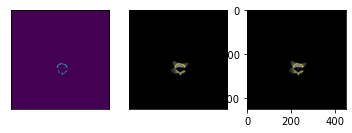

20 155


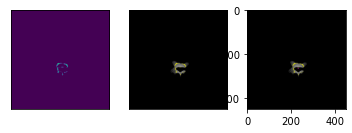

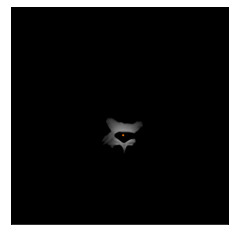

20 163
20 163
20 163
20 163
20 191
20 191
20 191
20 191
20 177
20 177
20 177
20 177
20 186
20 186
20 186
20 186
20 128
20 128
20 128
20 128
20 139
20 139
20 139
20 139
20 162
20 162
20 162
20 162
8
[195.71428571 194.85714286 193.85714286 153.42857143 180.28571429]
[ 20  54  94 120 149]


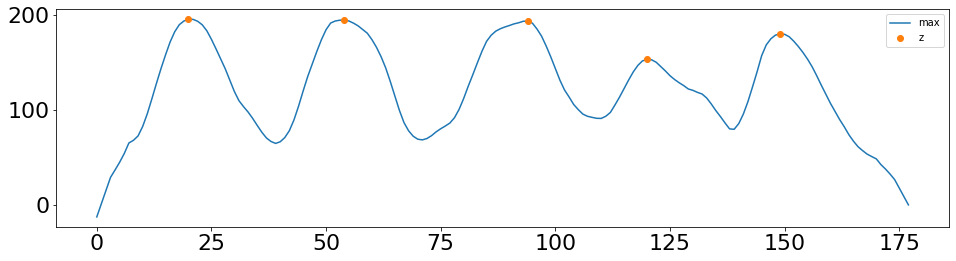

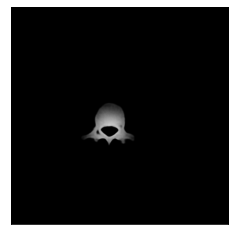

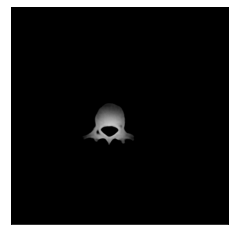

20 201


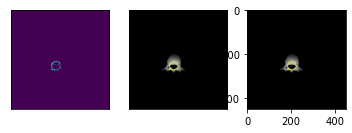

20 201


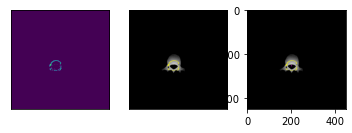

20 201


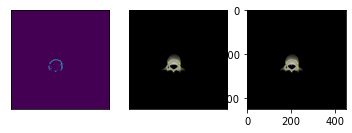

20 201


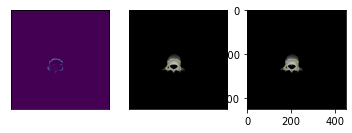

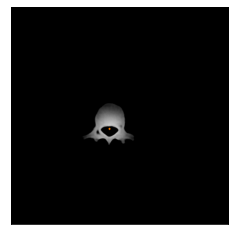

20 197
20 197
20 197
20 197
20 198
20 198
20 198
20 198
20 158
20 158
20 158
20 158
20 183
20 183
20 183
20 183
5
[130.57142857 158.         150.42857143 167.57142857 185.71428571
 161.14285714 137.71428571]
[  9  40  68  95 126 154 176]


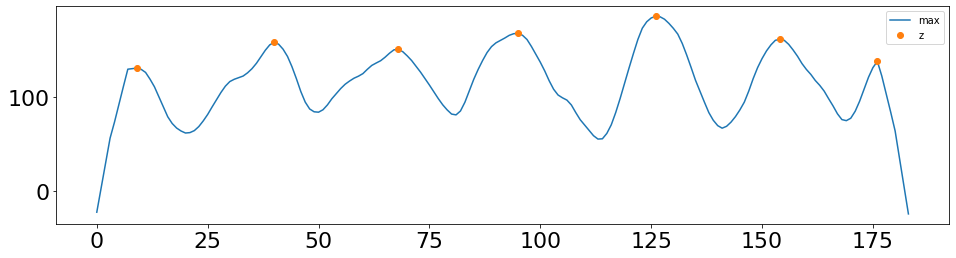

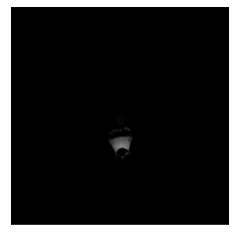

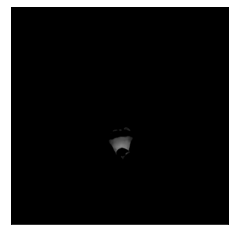

20 137


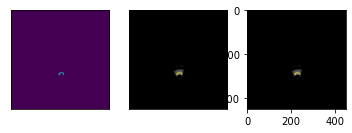

20 137


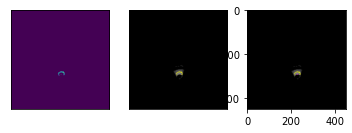

20 137


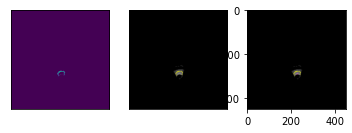

20 137


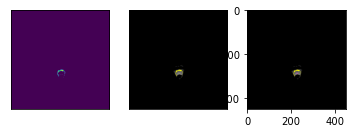

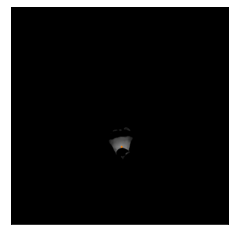

20 167
20 167
20 167
20 167
20 156
20 156
20 156
20 156
20 168
20 168
20 168
20 168
20 187
20 187
20 187
20 187
20 168
20 168
20 168
20 168
20 142
20 142
20 142
20 142
7
[145.14285714 180.28571429 175.42857143 156.42857143 209.85714286]
[ 26  53  79 104 129]


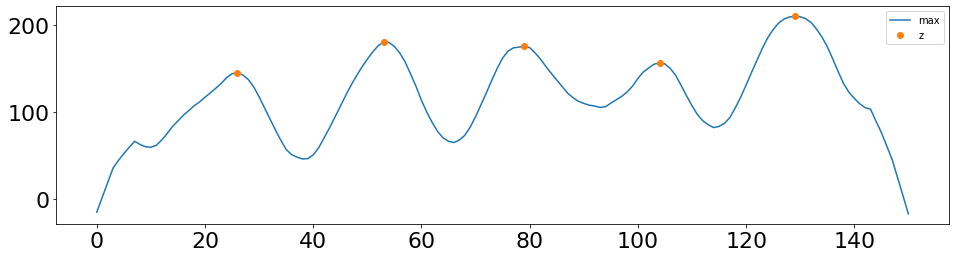

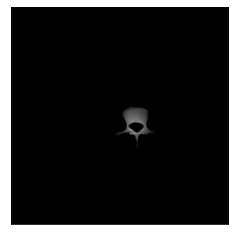

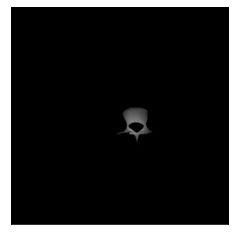

20 148


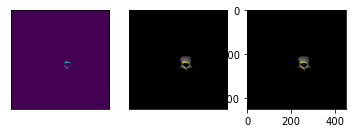

20 148


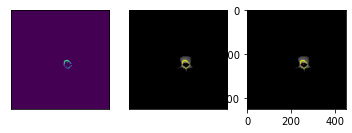

20 148


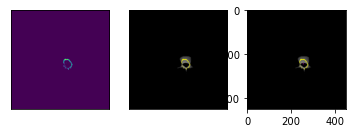

20 148


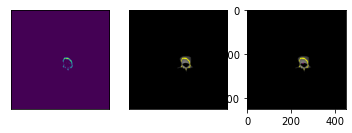

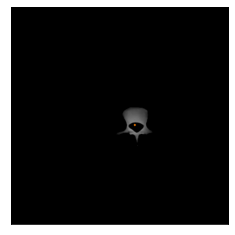

20 187
20 187
20 187
20 187
20 178
20 178
20 178
20 178
20 173
20 173
20 173
20 173
20 214
20 214
20 214
20 214
5


In [30]:
# 得到泛化能力测试的中心点坐标
i = 0
for pred_Dense in pred_Dense_folders:
    
    imagePath = rootPath + SrcmhdFolder + '/images/' + re.sub(r'pred_','',pred_Dense_folders[i]) + '.mhd'
    predsPath = pred_DensePath + pred_Dense + '/*.png'
    IJKPath = rootPath + SrcmhdFolder + "/pred_Centroids448/IJKpred/" + pred_Dense + '.csv'
    lenCentroids = GetCentroids(predsPath,IJKPath,imagePath,20)
    print(lenCentroids)
    i+=1

## Eval LE of Centroids

In [31]:
Centroids = sorted(glob(rootPath + SrcmhdFolder + '/Centroids/IJK/*.csv'))[10:]
Pred_Centroids = sorted(glob(rootPath + SrcmhdFolder + '/pred_Centroids448/IJKpred/*.csv'))#[0:1]

In [32]:
Centroids,Pred_Centroids

(['/home/shu/Dataset/Dataset xVertSeg/Spilt/Centroids/IJK/Splt_image011.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/Centroids/IJK/Splt_image012.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/Centroids/IJK/Splt_image013.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/Centroids/IJK/Splt_image014.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/Centroids/IJK/Splt_image015.csv'],
 ['/home/shu/Dataset/Dataset xVertSeg/Spilt/pred_Centroids448/IJKpred/pred_Splt_image011.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/pred_Centroids448/IJKpred/pred_Splt_image012.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/pred_Centroids448/IJKpred/pred_Splt_image013.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/pred_Centroids448/IJKpred/pred_Splt_image014.csv',
  '/home/shu/Dataset/Dataset xVertSeg/Spilt/pred_Centroids448/IJKpred/pred_Splt_image015.csv'])

In [35]:
npLE = GetLE(Centroids,Pred_Centroids)

In [34]:
npLE

array([2.93899361, 1.61536087, 4.87783104, 4.78444353, 1.89202511])